# RoBERTa-base

In [1]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

/Users/karol/Desktop/CoursesUwr/7sem/Modele_językowe/Project/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('news-article-categories.csv')
df['text'] = df['title'].fillna('') + ' ' + df['body'].fillna('')
le = LabelEncoder()
df['labels'] = le.fit_transform(df['category'].astype(str))
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_dataset = Dataset.from_pandas(train_df[['text', 'labels']])
test_dataset = Dataset.from_pandas(test_df[['text', 'labels']])

In [3]:
tokenizer = AutoTokenizer.from_pretrained('roberta-base')
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=256)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])


Map: 100%|██████████| 1376/1376 [00:00<00:00, 3600.00 examples/s]


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base', 
    num_labels=len(le.classes_)
)

training_args = TrainingArguments(
    output_dir='./results_roberta',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2662.63it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consid

In [5]:
trainer.train()
trainer.save_model('./roberta_model')
print(f"Categories: {le.classes_}")
results = trainer.evaluate()
print(results)


/Users/karol/Desktop/CoursesUwr/7sem/Modele_językowe/Project/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.667046,0.676949
2,0.637127,0.652117
3,0.326164,0.703916


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.15it/s]
/Users/karol/Desktop/CoursesUwr/7sem/Modele_językowe/Project/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.65it/s]
/Users/karol/Desktop/CoursesUwr/7sem/Modele_językowe/Project/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.54it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bi

Categories: ['ARTS & CULTURE' 'BUSINESS' 'COMEDY' 'CRIME' 'EDUCATION' 'ENTERTAINMENT'
 'ENVIRONMENT' 'MEDIA' 'POLITICS' 'RELIGION' 'SCIENCE' 'SPORTS' 'TECH'
 'WOMEN']


{'eval_loss': 0.6519644260406494, 'eval_runtime': 33.7794, 'eval_samples_per_second': 40.735, 'eval_steps_per_second': 5.092, 'epoch': 3.0}


In [6]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir='./results_roberta',
    per_device_eval_batch_size=16,
    dataloader_pin_memory=False,
    fp16=False
)

checkpoints = [d for d in os.listdir('./results_roberta') if d.startswith('checkpoint-')]
accuracy = []
loss = []
for checkpoint in checkpoints:
    model = AutoModelForSequenceClassification.from_pretrained(f"./results_roberta/{checkpoint}")
    trainer = Trainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        eval_dataset=test_dataset
    )
    results = trainer.evaluate()
    print(f"\nScores from {checkpoint}:")
    print(f"Accuracy: {results['eval_accuracy']:.1%}")
    accuracy.append(results['eval_accuracy'])
    print(f"Eval loss: {results['eval_loss']:.4f}")
    loss.append(results['eval_loss'])


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2837.11it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Scores from checkpoint-1376:
Accuracy: 82.5%
Eval loss: 0.6521


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2653.61it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Scores from checkpoint-688:
Accuracy: 79.6%
Eval loss: 0.6769


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2664.41it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Scores from checkpoint-2064:
Accuracy: 83.1%
Eval loss: 0.7039


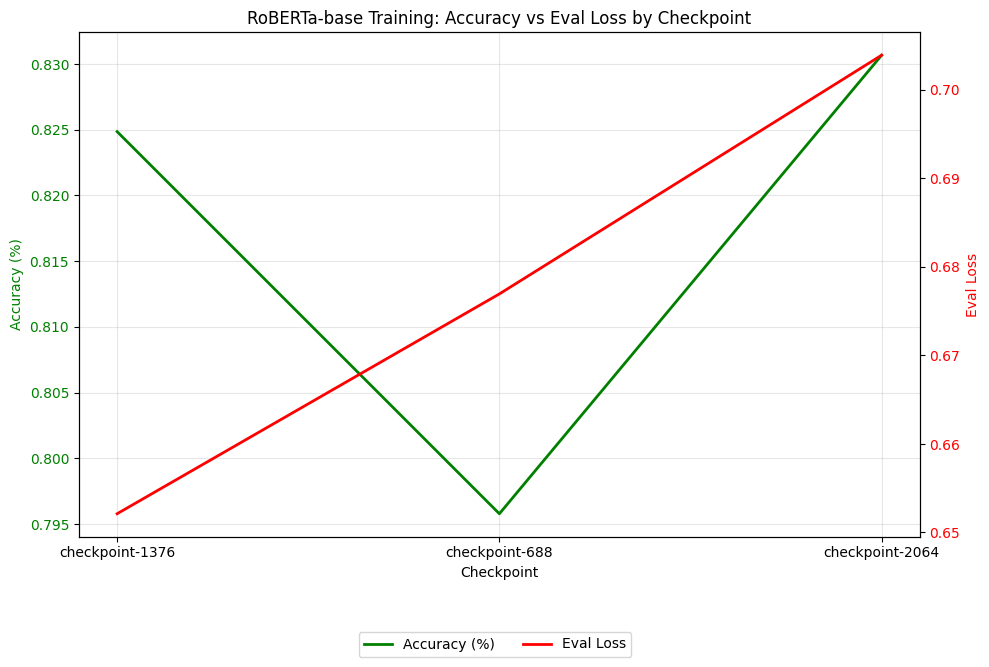

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(checkpoints, accuracy, color='green', linewidth=2, label='Accuracy (%)')
ax1.set_xlabel('Checkpoint')
ax1.set_ylabel('Accuracy (%)', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(checkpoints, loss, color='red', linewidth=2, label='Eval Loss')
ax2.set_ylabel('Eval Loss', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.title('RoBERTa-base Training: Accuracy vs Eval Loss by Checkpoint')
plt.tight_layout()
plt.show()
